## Linear Regression

### utils and helper imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lars
from sklearn.ensemble import AdaBoostRegressor
from sklearn.model_selection import train_test_split

### Import dataset

In [20]:
dataset = pd.read_csv("res/Salary_Data.csv")
dataset

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [28]:
X = dataset.iloc[:, :-1].values
Y = dataset.iloc[:, 1].values
X# print("X and Y")
# print(X, "\n\n", Y.reshape(-1,1), "\n")

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [38]:
#Splitting the dataset into train and test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)
print("X-train:", X_train, "\n\n", "X-test:", X_test, "\n")
#Reshape: Returns a new array (view) with the new shape.
print("Y-train:", Y_train.reshape(-1,1), "\n\n", "Y-test:", Y_test.reshape(-1,1), "\n")
#The -1 is just your "smart assistant" that counts the rows for you so you don't have to.

X-train: [[ 3.9]
 [ 9.5]
 [ 8.7]
 [ 9.6]
 [ 4. ]
 [ 5.3]
 [ 7.9]
 [ 2.9]
 [ 5.1]
 [ 3.2]
 [ 4.5]
 [ 8.2]
 [ 6.8]
 [ 1.3]
 [10.5]
 [ 3. ]
 [ 2.2]
 [ 5.9]
 [ 6. ]
 [ 3.7]
 [ 3.2]
 [ 9. ]
 [ 2. ]
 [ 1.1]
 [ 7.1]
 [ 4.9]
 [ 4. ]] 

 X-test: [[ 1.5]
 [10.3]
 [ 4.1]] 

Y-train: [[ 63218.]
 [116969.]
 [109431.]
 [112635.]
 [ 55794.]
 [ 83088.]
 [101302.]
 [ 56642.]
 [ 66029.]
 [ 64445.]
 [ 61111.]
 [113812.]
 [ 91738.]
 [ 46205.]
 [121872.]
 [ 60150.]
 [ 39891.]
 [ 81363.]
 [ 93940.]
 [ 57189.]
 [ 54445.]
 [105582.]
 [ 43525.]
 [ 39343.]
 [ 98273.]
 [ 67938.]
 [ 56957.]] 

 Y-test: [[ 37731.]
 [122391.]
 [ 57081.]] 




### Fitting Simple Linear Regression to the Training Set

LinearRegression() 

Y prediction 

[[ 40628.97301142]
 [123152.87216178]
 [ 65011.03412402]] 



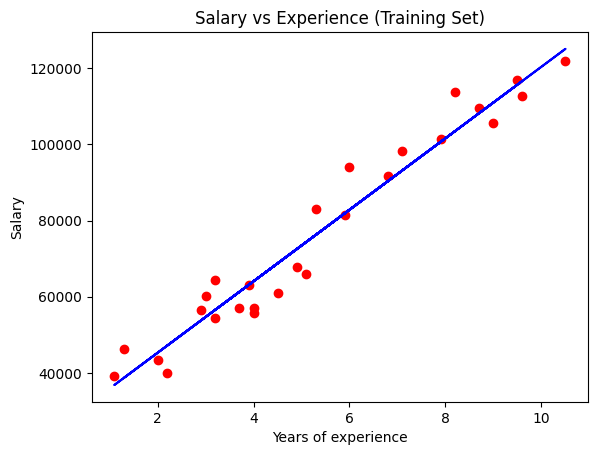

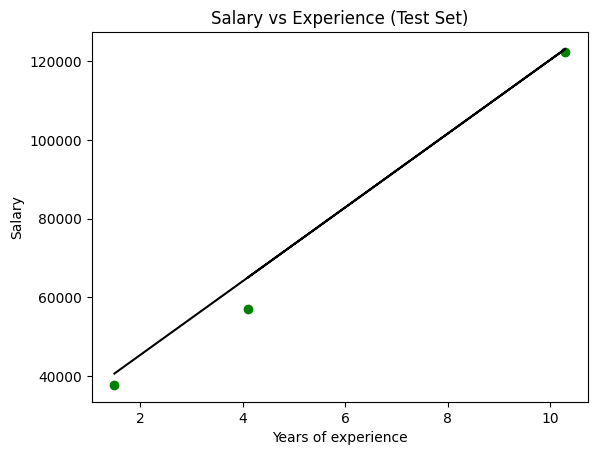

In [46]:

regressor = LinearRegression() #find the best fit line for the training data
regressor.fit(X_train, Y_train)
print(regressor,"\n")

#Predicting the test set results
Y_pred = regressor.predict(X_test)
# Y_pred = regressor.coef_*(X_test) + regressor.intercept_

print("Y prediction","\n")
# print(Y_pred.reshape,"\n")
print(Y_pred.reshape(-1,1),"\n")

#Visualizing the Training Set Results
plt.scatter(X_train, Y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title("Salary vs Experience (Training Set)")
plt.xlabel("Years of experience")
plt.ylabel("Salary")
plt.show()

#Visualizing the Test Set Results
plt.scatter(X_test, Y_test, color='green')
plt.plot(X_test, Y_pred, color='black')
plt.title("Salary vs Experience (Test Set)")
plt.xlabel("Years of experience")
plt.ylabel("Salary")
plt.show()

# Logistic Regression

### utils and Importing the libraries

### Load dataset

In [ ]:
dataset = pd.read_csv('res/Social_Network_Ads.csv')
X = dataset.iloc[:, [2, 3]].values
Y = dataset.iloc[:, 4].values

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler() #StandardScaler converts both columns so they have a Mean of 0 and a Standard Deviation of 1
X_train = sc.fit_transform(X_train) #We fit on the training data to learn the average and spread.
X_test = sc.transform(X_test) #We only transform the test data using those same rules (because in the real world, you wouldn't know the "average" of future data).

In [48]:
# Check for missing values
print(dataset.isnull().sum())

# Option A: Drop rows with any empty values
dataset = dataset.dropna()

# Option B: Fill empty values with the mean (Average)
dataset['Age'] = dataset['Age'].fillna(dataset['Age'].mean())
dataset['EstimatedSalary'] = dataset['EstimatedSalary'].fillna(dataset['EstimatedSalary'].mean())

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [51]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix,accuracy_score


def plot_boundary(X_set,Y_set, clf):
    #Visualizing Testing Set Results
    from matplotlib.colors import ListedColormap
    colors =["green", "orange", "gold", "blue", "k", "purple","red"]

    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                        np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
                                        alpha = 0.75, cmap = ListedColormap(colors))
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate (np.unique(Y_set)):
        plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],
                    c = ListedColormap(colors)(i), label = j)
    plt.title('Classify users if they buy the Car')
    plt.xlabel('Age')
    plt.ylabel('Estimated Salary')
    plt.legend()
    plt.show()

### Fit Model on dataset 

[[65  3]
 [ 8 24]]
0.89


C:\Users\hp\AppData\Local\Temp\ipykernel_19344\462264545.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],


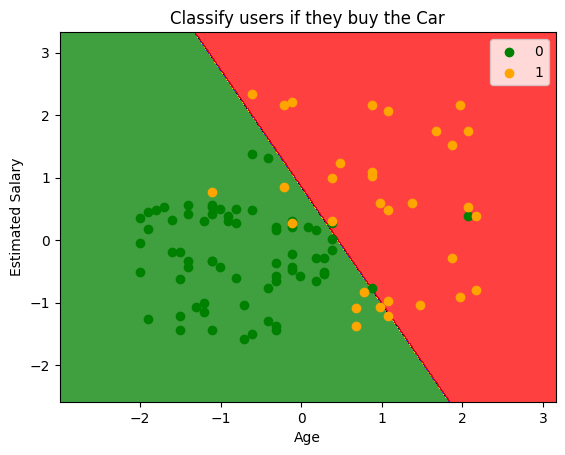

In [64]:
#Fitting Logistic Regression to the Training Set
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
classifier = LogisticRegression()
# classifier = SVC()
classifier.fit(X_train, Y_train)

#Predicting the Test set results
Y_pred = classifier.predict(X_test)

#Making the Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm) #shows the number of correct predictions made
result_acc = accuracy_score(Y_test, Y_pred)
print(result_acc)

plot_boundary(X_test, Y_test, classifier)


[[64  4]
 [ 3 29]]
0.93


C:\Users\hp\AppData\Local\Temp\ipykernel_19344\462264545.py:19: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[Y_set == j, 0], X_set[Y_set == j, 1],


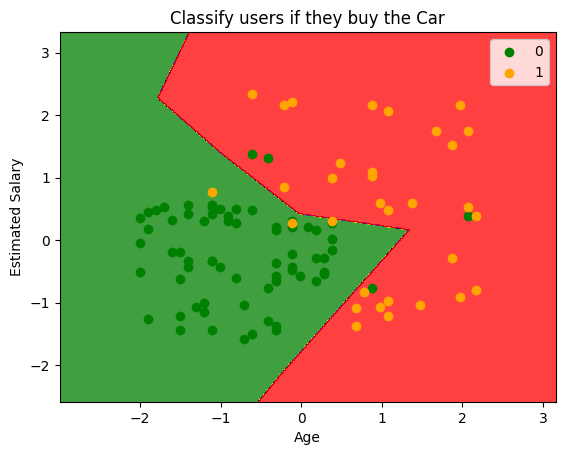

In [65]:
from sklearn.neural_network import MLPClassifier
classifier_nn = MLPClassifier(solver='lbfgs', alpha=1e-4,
                    hidden_layer_sizes=(5, 2), random_state=1)
#solver='lbfgs': The learning method. It's a high-performance math trick used to find the best weights for the neurons quickly.
# Layer 1: Use 5 neurons and Layer 2: Use 2 neurons

classifier_nn.fit(X_train, Y_train)

#Predicting the Test set results
Y_pred = classifier_nn.predict(X_test)

#Making the Confusion Matrix
cm = confusion_matrix(Y_test, Y_pred)
print(cm) #shows the number of correct predictions made
result_acc = accuracy_score(Y_test, Y_pred)
print(result_acc)


plot_boundary(X_test, Y_test, classifier_nn)

# Linear Classifier

### Imports and utils 

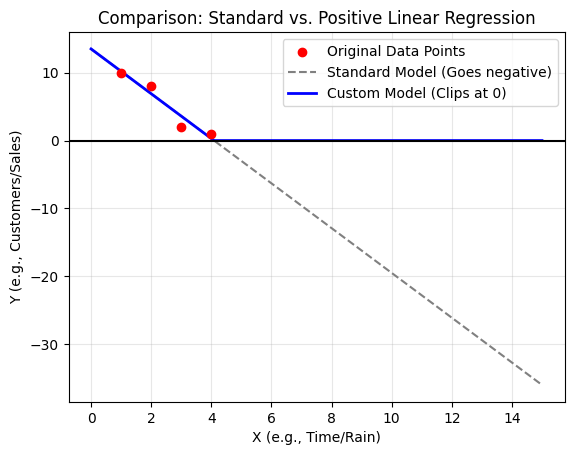

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Define the custom class
class PositiveLinearRegression(LinearRegression):
    def predict(self, X):
        # Calculate raw math (can be negative)
        predictions = super().predict(X)
        # Force a minimum of 0
        return np.maximum(predictions, 0)

# 2. Sample data (Downward trend)
X = np.array([[1], [2], [3], [4]])
y = np.array([10, 8, 2, 1])

# 3. Fit both the custom model and a standard one for comparison
custom_model = PositiveLinearRegression()
custom_model.fit(X, y)

standard_model = LinearRegression()
standard_model.fit(X, y)

# 4. Create a range of X values from 0 to 15 to see the "future"
X_plot = np.linspace(0, 15, 100).reshape(-1, 1)

# 5. Get predictions from both
y_custom = custom_model.predict(X_plot)
y_standard = standard_model.predict(X_plot)

# 6. Plotting
plt.scatter(X, y, color='red', label='Original Data Points', zorder=5)
plt.plot(X_plot, y_standard, color='gray', linestyle='--', label='Standard Model (Goes negative)')
plt.plot(X_plot, y_custom, color='blue', linewidth=2, label='Custom Model (Clips at 0)')

# Formatting the chart
plt.axhline(0, color='black', linewidth=1.5) # The "Floor" at zero
plt.title("Comparison: Standard vs. Positive Linear Regression")
plt.xlabel("X (e.g., Time/Rain)")
plt.ylabel("Y (e.g., Customers/Sales)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('comparison_plot.png')

In [ ]:
# #Linear classifier from scratch
# from sklearn.datasets import make_classification
# from sklearn.datasets import make_circles
# import numpy as np
# import matplotlib.pyplot as plt


# class LinearClassifier:
#     def __init__(self):
#         pass
#     def sigmoid(self,z):
#         return 1.0/(1. + np.exp(-z))

#     def loss(self,y,y_ht):
#         loss =  -np.mean( y*(np.log(y_ht)) - (1-y)*np.log(1-y_ht) )
#         return loss

#     def gradient(self,x,y,y_ht):
#         m = x.shape[0]
#         dw = (1/m)*np.dot(x.T,(y_ht-y)) #wrt w
#         db = (1/m)*np.sum((y_ht-y)) # wrt bias
#         return dw,db 

#     def normalize(self,x):
#         m,n = x.shape   #m : trg exmple, n: features
#         for i in range(n):
#             x = (x - x.mean(axis=0))/x.std(axis=0)
#         return x    

#     def train(self, x,y,bs,epochs,lr):
#         m,n = x.shape
#         w = np.zeros((n,1))  ## or random ?
#         b = 0
#         y = y.reshape(m,1)
#         x = self.normalize(x)

#         losses = []

#         for epoch in range(epochs):
#             for i in range((m-1)//bs+1):
#                 start_i = i*bs
#                 end_i = start_i + bs
#                 xb = x[start_i:end_i]
#                 yb = y[start_i:end_i]

#                 y_ht = self.sigmoid(np.dot(xb,w)+b)

#                 dw,db = self.gradient(xb,yb,y_ht)

#                 w -=lr*dw
#                 b -=lr*db

#             l = self.loss(y,self.sigmoid(np.dot(x,w)+b))
#             losses.append(l)
#             # self.plot_dec_boundry(x,w,b,y,1)

#         return w,b,losses


#     def predict(self,x,w,b):

#         x = self.normalize(x)
#         preds = self.sigmoid((np.dot(x,w)+b))
#         pred_class = []

#         pred_class = [1 if i>0.5 else 0 for i in preds]

#         return np.array(pred_class)
    
#     def accuracy(self,y, y_ht):
#         accuracy = np.sum(y == y_ht) / len(y)
#         return accuracy

#     def plot_dec_boundry(self,x,w,b,y,debug):
#         x1 = [min(x[:,0]), max(x[:,0])]
#         m = -w[0]/w[1]
#         c = -b/w[1]
#         x2 = m*x1 + c
#         plt.plot(x[:,0][y==0], x[:,1][y==0],'r^')
#         plt.plot(x[:,0][y==1], x[:,1][y==1],'bs')
#         plt.plot(x1,x2,'y-')
#         if debug:
#             plt.show()


### init and fit Classifier 

In [ ]:
# x,Y = make_classification(n_features=2,n_classes=2,n_samples=100,n_redundant=0,n_clusters_per_class=1)
# # x,Y = make_circles(n_samples=100,noise=0.03,factor=0.7)

# p = LinearClassifier()
# w,b,loss = p.train(x,Y,bs=10,epochs=9000,lr=0.01)
# print(w,b)
# class_pred = p.predict(x,w,b)
# print('Accuracy= ',p.accuracy(Y,class_pred) * 100,'%')
# plt.subplot(1,2,1)
# p.plot_dec_boundry(x,w,b,Y,0)
# plt.subplot(1,2,2)
# plt.plot(loss)
# plt.suptitle(['Accuray' + str(p.accuracy(Y,class_pred) * 100)])
# plt.show()


